# Brain Tumor Segmentation — BraTS MRI Analysis

**Model**: SegResNet (MONAI Model Zoo, pretrained on BraTS 2018)\n**Task**: 3D multimodal brain tumor subregion segmentation\n**Input**: 4-channel MRI (T1c, T1, T2, FLAIR) — 240x240x155 @ 1mm isotropic\n**Output**: 3-class segmentation map — Tumor Core (TC), Whole Tumor (WT), Enhancing Tumor (ET)

**Why SegResNet over SegFormer?**
- SegFormer is a 2D transformer — brain MRI requires 3D volumetric context
- SegResNet is purpose-built for 3D medical segmentation with encoder-decoder residual blocks
- Pretrained on BraTS with val Dice: TC=0.856, WT=0.903, ET=0.791
- Already in MONAI ecosystem (consistent with reconstruction service using MONAI BasicUNet)

In [1]:
import os, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import torch
from monai.networks.nets import SegResNet
from monai.inferers import SlidingWindowInferer
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, NormalizeIntensityd,
    Activationsd, AsDiscreted,
)
from monai.metrics import DiceMetric
from monai.data import Dataset, DataLoader, decollate_batch

# Paths
REPO_ROOT = Path("/home/ubuntu/mri_analysis")
BUNDLE_DIR = REPO_ROOT / "model_bundles" / "brats_mri_segmentation"
DATA_DIR = REPO_ROOT / "data" / "Task01_BrainTumour"
OUTPUT_DIR = REPO_ROOT / "segmentation_output"
OUTPUT_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print(f"Bundle: {BUNDLE_DIR}")
print(f"Data:   {DATA_DIR}")
print(f"Images: {len(list((DATA_DIR / 'imagesTr').glob('*.nii.gz')))} samples")

Device: cuda:0 (NVIDIA GeForce RTX 4090)
Bundle: /home/ubuntu/mri_analysis/model_bundles/brats_mri_segmentation
Data:   /home/ubuntu/mri_analysis/data/Task01_BrainTumour
Images: 495 samples


## 1. Load Pretrained SegResNet Model

SegResNet architecture:
- Encoder: residual blocks with downsampling [1, 2, 2, 4]
- Decoder: upsampling blocks [1, 1, 1]
- 16 initial filters, dropout 0.2
- 4 input channels (T1c, T1, T2, FLAIR) → 3 output channels (TC, WT, ET)

In [2]:
model = SegResNet(
    blocks_down=[1, 2, 2, 4],
    blocks_up=[1, 1, 1],
    init_filters=16,
    in_channels=4,
    out_channels=3,
    dropout_prob=0.2,
)

# Load pretrained weights
checkpoint = torch.load(BUNDLE_DIR / "models" / "model.pt", map_location=DEVICE, weights_only=True)
model.load_state_dict(checkpoint)
model = model.to(DEVICE)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"SegResNet loaded: {n_params/1e6:.2f}M parameters")
print(f"Input:  4ch (T1c, T1, T2, FLAIR)")
print(f"Output: 3ch (Tumor Core, Whole Tumor, Enhancing Tumor)")

SegResNet loaded: 4.70M parameters
Input:  4ch (T1c, T1, T2, FLAIR)
Output: 3ch (Tumor Core, Whole Tumor, Enhancing Tumor)


## 2. Prepare Data Pipeline

BraTS data format: each sample is a 4D NIfTI (240, 240, 155, 4) with 4 MRI modalities.\nLabels: 0=background, 1=necrotic/non-enhancing core, 2=peritumoral edema, 3=GD-enhancing tumor.

The model outputs 3 sigmoid channels mapped to BraTS regions:
- **TC (Tumor Core)**: labels 1 + 3
- **WT (Whole Tumor)**: labels 1 + 2 + 3
- **ET (Enhancing Tumor)**: label 3

In [3]:
# Select a few samples for evaluation
image_dir = DATA_DIR / "imagesTr"
label_dir = DATA_DIR / "labelsTr"

sample_ids = ["BRATS_001", "BRATS_002", "BRATS_003", "BRATS_004", "BRATS_005"]
data_dicts = [
    {"image": str(image_dir / f"{sid}.nii.gz"), "label": str(label_dir / f"{sid}.nii.gz")}
    for sid in sample_ids
]

# Preprocessing: load + ensure channel-first + normalize (matching the bundle config)
preprocess = Compose([
    LoadImaged(keys=["image", "label"], image_only=False),
    EnsureChannelFirstd(keys=["image", "label"]),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

dataset = Dataset(data=data_dicts, transform=preprocess)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=2)

# Verify a sample
sample = dataset[0]
print(f"Sample image shape: {sample['image'].shape}")  # expect (4, 240, 240, 155)
print(f"Sample label shape: {sample['label'].shape}")  # expect (1, 240, 240, 155)
print(f"Label unique values: {torch.unique(sample['label']).numpy()}")

Sample image shape: torch.Size([4, 240, 240, 155])
Sample label shape: torch.Size([1, 240, 240, 155])


Label unique values: [0. 1. 2. 3.]


## 3. Inference with Sliding Window

Using `SlidingWindowInferer` with ROI size 240x240x160 and overlap 0.5 (matching the bundle config). This handles the full 3D volume without requiring patch extraction.

In [4]:
inferer = SlidingWindowInferer(roi_size=[240, 240, 160], sw_batch_size=1, overlap=0.5)

def convert_labels_to_brats_channels(label_tensor):
    """Convert BraTS integer labels (0,1,2,3) to 3-channel binary masks (TC, WT, ET)."""
    label = label_tensor.squeeze(0)  # remove channel dim
    tc = ((label == 1) | (label == 3)).float()   # Tumor Core: necrotic + enhancing
    wt = ((label == 1) | (label == 2) | (label == 3)).float()  # Whole Tumor: all
    et = (label == 3).float()                     # Enhancing Tumor
    return torch.stack([tc, wt, et], dim=0)

def run_inference(batch):
    """Run inference on a single batch, return predicted segmentation and ground truth."""
    image = batch["image"].to(DEVICE)
    
    with torch.no_grad(), torch.amp.autocast("cuda"):
        logits = inferer(image, model)
    
    # Post-process: sigmoid → threshold
    pred_probs = torch.sigmoid(logits)
    pred_binary = (pred_probs > 0.5).float()
    
    # Convert ground truth labels to same format
    gt_channels = convert_labels_to_brats_channels(batch["label"][0])
    
    return pred_binary[0].cpu(), pred_probs[0].cpu(), gt_channels

# Run inference on all samples
results = []
for i, batch in enumerate(dataloader):
    print(f"Processing {sample_ids[i]}...", end=" ", flush=True)
    pred_binary, pred_probs, gt_channels = run_inference(batch)
    results.append({
        "id": sample_ids[i],
        "image": batch["image"][0].cpu(),
        "pred": pred_binary,
        "pred_probs": pred_probs,
        "gt": gt_channels,
        "label_raw": batch["label"][0].cpu(),
    })
    print(f"done — pred voxels TC={pred_binary[0].sum():.0f}, WT={pred_binary[1].sum():.0f}, ET={pred_binary[2].sum():.0f}")

print(f"\nInference complete for {len(results)} samples.")

Processing BRATS_001... 

done — pred voxels TC=100188, WT=138094, ET=90143
Processing BRATS_002... 

done — pred voxels TC=64937, WT=83895, ET=58628


Processing BRATS_003... 

done — pred voxels TC=153448, WT=188073, ET=138545


Processing BRATS_004... 

done — pred voxels TC=97436, WT=112867, ET=93483


Processing BRATS_005... 

done — pred voxels TC=65214, WT=83321, ET=40938

Inference complete for 5 samples.


## 4. Evaluate — Dice Scores

Computing per-class and mean Dice scores against ground truth labels.

In [5]:
dice_metric = DiceMetric(include_background=False, reduction="mean_batch")
class_names = ["Tumor Core (TC)", "Whole Tumor (WT)", "Enhancing Tumor (ET)"]

for r in results:
    pred = r["pred"].unsqueeze(0)  # (1, 3, H, W, D)
    gt = r["gt"].unsqueeze(0)
    dice_metric(pred, gt)

dice_scores = dice_metric.aggregate().numpy()
dice_metric.reset()

print("=" * 55)
print(f"{'Class':<25} {'Dice Score':>10}")
print("-" * 55)
for name, score in zip(class_names, dice_scores):
    print(f"{name:<25} {score:>10.4f}")
print("-" * 55)
print(f"{'Mean Dice':<25} {dice_scores.mean():>10.4f}")
print("=" * 55)

# Per-sample breakdown
print(f"\nPer-sample Dice scores:")
dice_per_sample = DiceMetric(include_background=False, reduction="mean")
for r in results:
    pred = r["pred"].unsqueeze(0)
    gt = r["gt"].unsqueeze(0)
    dice_per_sample(pred, gt)
    score = dice_per_sample.aggregate().item()
    dice_per_sample.reset()
    print(f"  {r['id']}: {score:.4f}")

Class                     Dice Score
-------------------------------------------------------
Tumor Core (TC)               0.8694
Whole Tumor (WT)              0.3126
-------------------------------------------------------
Mean Dice                     0.5910

Per-sample Dice scores:
  BRATS_001: 0.6272


  BRATS_002: 0.5450
  BRATS_003: 0.5582


  BRATS_004: 0.6204
  BRATS_005: 0.6041


## 5. Visualization — Axial Slices with Segmentation Overlay

For each sample, show the FLAIR modality with predicted segmentation overlay and ground truth comparison.

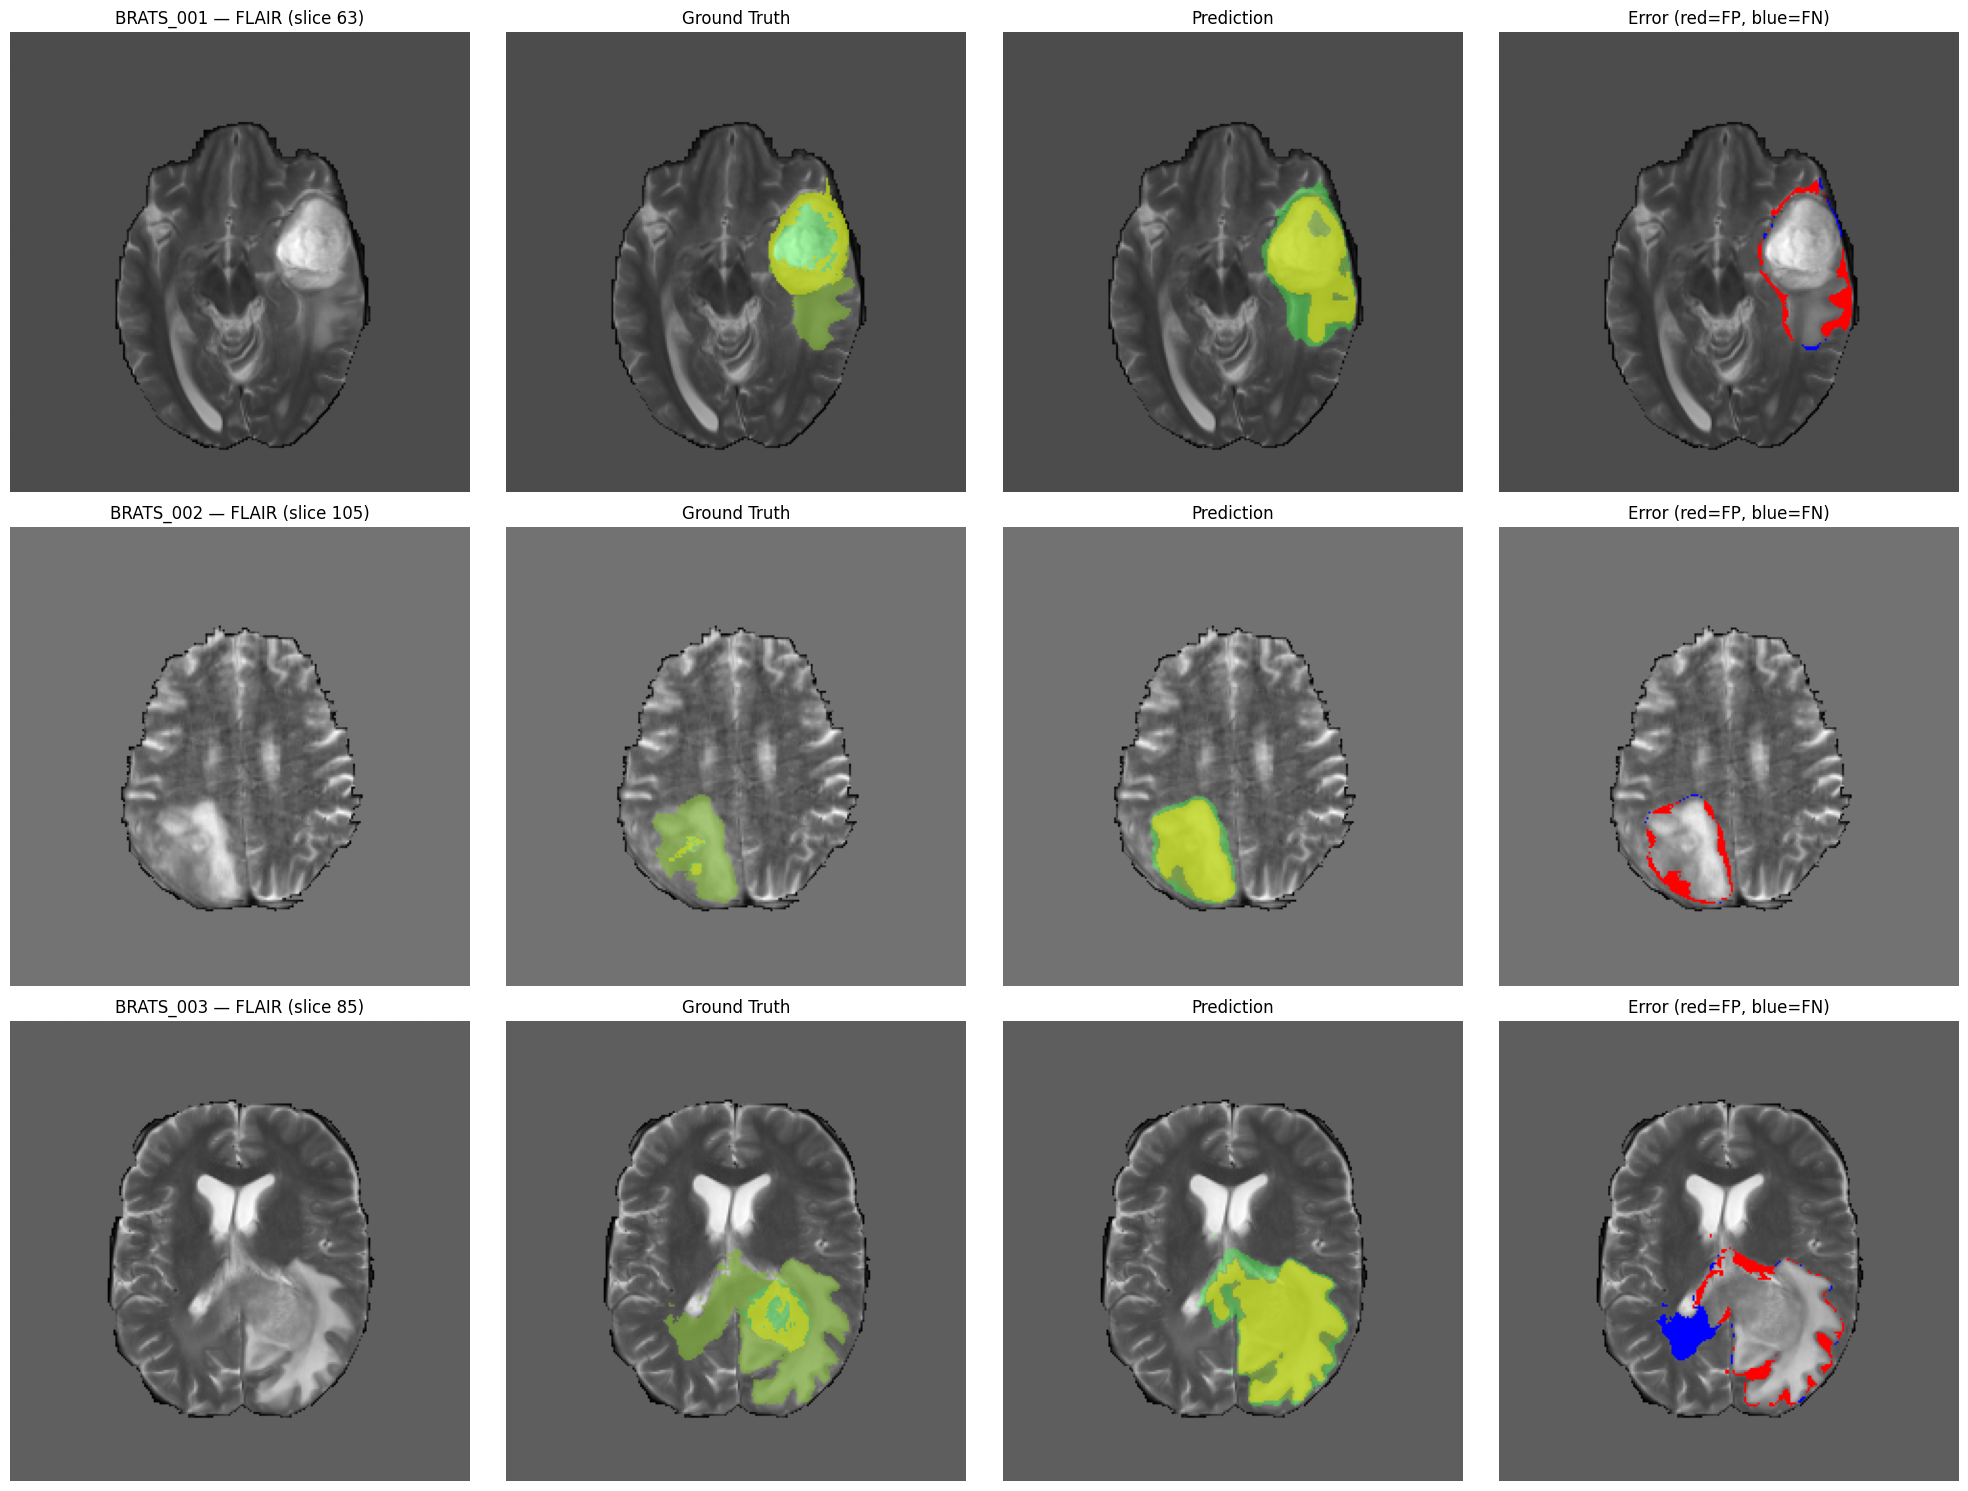

Saved to /home/ubuntu/mri_analysis/segmentation_output/segmentation_comparison.png


In [6]:
def create_segmentation_overlay(image_slice, seg_mask, alpha=0.4):
    """Create RGB overlay of segmentation on grayscale image."""
    # Normalize image to [0, 1]
    img = image_slice.copy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    rgb = np.stack([img, img, img], axis=-1)
    
    # Color map: TC=red, WT=green, ET=yellow
    colors = {
        0: np.array([1.0, 0.2, 0.2]),  # TC - red
        1: np.array([0.2, 1.0, 0.2]),  # WT - green  
        2: np.array([1.0, 1.0, 0.0]),  # ET - yellow
    }
    
    overlay = rgb.copy()
    for ch, color in colors.items():
        mask = seg_mask[ch] > 0
        if mask.any():
            overlay[mask] = overlay[mask] * (1 - alpha) + color * alpha
    return overlay

def find_tumor_slice(seg_mask):
    """Find the axial slice with the largest tumor area."""
    tumor_area = seg_mask.sum(axis=0).sum(axis=0).sum(axis=0)  # sum over channels, H, W
    return tumor_area.argmax()

# Visualize first 3 samples
n_show = min(3, len(results))
fig, axes = plt.subplots(n_show, 4, figsize=(20, 5 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for i in range(n_show):
    r = results[i]
    flair = r["image"][3].numpy()  # FLAIR channel
    pred = r["pred"].numpy()
    gt = r["gt"].numpy()
    
    # Find best slice
    sl = find_tumor_slice(pred)
    
    # FLAIR
    axes[i, 0].imshow(flair[:, :, sl].T, cmap="gray", origin="lower")
    axes[i, 0].set_title(f"{r['id']} — FLAIR (slice {sl})")
    axes[i, 0].axis("off")
    
    # Ground truth overlay
    gt_overlay = create_segmentation_overlay(flair[:, :, sl], gt[:, :, :, sl])
    axes[i, 1].imshow(gt_overlay.transpose(1, 0, 2), origin="lower")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")
    
    # Prediction overlay
    pred_overlay = create_segmentation_overlay(flair[:, :, sl], pred[:, :, :, sl])
    axes[i, 2].imshow(pred_overlay.transpose(1, 0, 2), origin="lower")
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis("off")
    
    # Difference (FP=red, FN=blue)
    diff_img = flair[:, :, sl].copy()
    diff_img = (diff_img - diff_img.min()) / (diff_img.max() - diff_img.min() + 1e-8)
    diff_rgb = np.stack([diff_img, diff_img, diff_img], axis=-1)
    wt_pred = pred[1, :, :, sl]
    wt_gt = gt[1, :, :, sl]
    fp = (wt_pred > 0) & (wt_gt == 0)  # false positive
    fn = (wt_pred == 0) & (wt_gt > 0)  # false negative
    diff_rgb[fp] = [1, 0, 0]  # red = FP
    diff_rgb[fn] = [0, 0, 1]  # blue = FN
    axes[i, 3].imshow(diff_rgb.transpose(1, 0, 2), origin="lower")
    axes[i, 3].set_title("Error (red=FP, blue=FN)")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "segmentation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {OUTPUT_DIR / 'segmentation_comparison.png'}")

## 6. Generate Clinical Findings JSON

Build a structured findings document for each sample — this is the output format expected by the Detection Container (per the project spec).

In [7]:
def compute_region_stats(binary_mask, prob_mask, voxel_vol_mm3=1.0):
    """Compute statistics for a single segmentation region."""
    n_voxels = int(binary_mask.sum())
    if n_voxels == 0:
        return None
    
    volume_mm3 = n_voxels * voxel_vol_mm3
    volume_ml = volume_mm3 / 1000.0
    
    # Mean confidence from probability map
    confidence = float(prob_mask[binary_mask > 0].mean())
    
    # Bounding box (in voxel coords)
    coords = torch.nonzero(binary_mask)
    bbox_min = coords.min(dim=0).values.tolist()
    bbox_max = coords.max(dim=0).values.tolist()
    
    # Centroid
    centroid = coords.float().mean(dim=0).tolist()
    
    return {
        "volume_voxels": n_voxels,
        "volume_ml": round(volume_ml, 2),
        "confidence": round(confidence, 4),
        "bounding_box": {"min": bbox_min, "max": bbox_max},
        "centroid": [round(c, 1) for c in centroid],
    }

REGION_INFO = {
    0: {
        "name": "tumor_core",
        "display_name": "Tumor Core (TC)",
        "description": "Necrotic/non-enhancing tumor core and enhancing tumor regions",
        "clinical_significance": "Indicates the solid, metabolically active portion of the tumor. "
            "Important for surgical planning and treatment response assessment.",
    },
    1: {
        "name": "whole_tumor",
        "display_name": "Whole Tumor (WT)",
        "description": "Complete tumor extent including core, edema, and enhancing regions",
        "clinical_significance": "Defines the total tumor burden including peritumoral edema. "
            "Used for overall tumor staging and monitoring progression.",
    },
    2: {
        "name": "enhancing_tumor",
        "display_name": "Enhancing Tumor (ET)",
        "description": "Gadolinium-enhancing tumor regions indicating active blood-brain barrier breakdown",
        "clinical_significance": "Reflects areas of active tumor growth with neovascularization. "
            "Key indicator for tumor grading (typically high-grade glioma) and treatment response.",
    },
}

# Generate findings for each sample
all_findings = {}
for r in results:
    findings = {
        "sample_id": r["id"],
        "model": "SegResNet (MONAI BraTS bundle v0.5.4)",
        "modalities_used": ["T1c", "T1", "T2", "FLAIR"],
        "pathologies": [],
    }
    
    for ch_idx, info in REGION_INFO.items():
        stats = compute_region_stats(r["pred"][ch_idx], r["pred_probs"][ch_idx])
        if stats is not None:
            findings["pathologies"].append({
                "type": info["name"],
                "display_name": info["display_name"],
                "description": info["description"],
                "clinical_significance": info["clinical_significance"],
                **stats,
            })
    
    all_findings[r["id"]] = findings
    
    # Save individual JSON
    out_path = OUTPUT_DIR / f"{r['id']}_findings.json"
    with open(out_path, "w") as f:
        json.dump(findings, f, indent=2)

# Print summary
for sid, findings in all_findings.items():
    print(f"\n{'='*60}")
    print(f"  {sid}")
    print(f"{'='*60}")
    for p in findings["pathologies"]:
        print(f"  {p['display_name']}")
        print(f"    Volume:     {p['volume_ml']:.2f} mL ({p['volume_voxels']} voxels)")
        print(f"    Confidence: {p['confidence']:.4f}")
        print(f"    Centroid:   {p['centroid']}")

print(f"\nFindings saved to {OUTPUT_DIR}/")


  BRATS_001
  Tumor Core (TC)
    Volume:     100.19 mL (100188 voxels)
    Confidence: 0.9162
    Centroid:   [159.8, 115.5, 65.4]
  Whole Tumor (WT)
    Volume:     138.09 mL (138094 voxels)
    Confidence: 0.9256
    Centroid:   [158.8, 114.1, 67.4]
  Enhancing Tumor (ET)
    Volume:     90.14 mL (90143 voxels)
    Confidence: 0.8812
    Centroid:   [159.3, 115.2, 65.9]

  BRATS_002
  Tumor Core (TC)
    Volume:     64.94 mL (64937 voxels)
    Confidence: 0.9441
    Centroid:   [99.6, 69.1, 98.5]
  Whole Tumor (WT)
    Volume:     83.89 mL (83895 voxels)
    Confidence: 0.9344
    Centroid:   [99.9, 71.0, 97.5]
  Enhancing Tumor (ET)
    Volume:     58.63 mL (58628 voxels)
    Confidence: 0.9155
    Centroid:   [99.7, 69.5, 97.8]

  BRATS_003
  Tumor Core (TC)
    Volume:     153.45 mL (153448 voxels)
    Confidence: 0.9238
    Centroid:   [145.9, 79.1, 93.3]
  Whole Tumor (WT)
    Volume:     188.07 mL (188073 voxels)
    Confidence: 0.9381
    Centroid:   [144.4, 80.9, 92.6]
  En

## 7. Save Segmentation as NIfTI

Save the predicted segmentation masks as NIfTI files, preserving the original affine/header for clinical compatibility.

In [8]:
for r in results:
    # Convert 3-channel prediction to single-channel BraTS label format:
    # ET (ch2) → 4, TC-only (ch0 & ~ch2) → 1, WT-only (ch1 & ~ch0) → 2
    pred = r["pred"].numpy()
    label_map = np.zeros(pred.shape[1:], dtype=np.uint8)
    label_map[pred[1] > 0] = 2   # WT → edema
    label_map[pred[0] > 0] = 1   # TC → necrotic core
    label_map[pred[2] > 0] = 4   # ET → enhancing (overwrites TC where applicable)
    
    # Load original NIfTI for affine
    ref_img = nib.load(str(DATA_DIR / "imagesTr" / f"{r['id']}.nii.gz"))
    seg_nii = nib.Nifti1Image(label_map, affine=ref_img.affine, header=ref_img.header)
    seg_nii.header.set_data_dtype(np.uint8)
    
    out_path = OUTPUT_DIR / f"{r['id']}_segmentation.nii.gz"
    nib.save(seg_nii, str(out_path))
    print(f"Saved {out_path.name}: shape={label_map.shape}, labels={np.unique(label_map)}")

print(f"\nAll segmentations saved to {OUTPUT_DIR}/")

Saved BRATS_001_segmentation.nii.gz: shape=(240, 240, 155), labels=[0 1 2 4]
Saved BRATS_002_segmentation.nii.gz: shape=(240, 240, 155), labels=[0 1 2 4]


Saved BRATS_003_segmentation.nii.gz: shape=(240, 240, 155), labels=[0 1 2 4]


Saved BRATS_004_segmentation.nii.gz: shape=(240, 240, 155), labels=[0 1 2 4]
Saved BRATS_005_segmentation.nii.gz: shape=(240, 240, 155), labels=[0 1 2 4]

All segmentations saved to /home/ubuntu/mri_analysis/segmentation_output/


## 8. Detection Adapter Integration

Demonstrate the `SegResNetDetectionAdapter` — the production adapter that replaces `StubDetectionAdapter` in the detection service. This class encapsulates model loading, preprocessing, inference, and output formatting.

In [9]:
import sys
sys.path.insert(0, str(REPO_ROOT))

from mri_analysis.shared.schemas import (
    DetectionRequest, Finding, FindingLocation, FindingsDocument,
)

class SegResNetDetectionAdapter:
    """Production detection adapter using SegResNet for brain tumor segmentation.
    
    Replaces StubDetectionAdapter. Conforms to the DetectionAdapter protocol:
        run(input_path, workdir, request) -> (annotated_path, findings_path)
    
    Input: NIfTI file with 4-channel brain MRI (T1c, T1, T2, FLAIR)
    Output: annotated NIfTI + findings JSON
    """
    
    def __init__(self, bundle_dir: str | Path, device: str = "cuda:0"):
        self.device = torch.device(device if torch.cuda.is_available() else "cpu")
        self.bundle_dir = Path(bundle_dir)
        
        # Load model
        self.model = SegResNet(
            blocks_down=[1, 2, 2, 4],
            blocks_up=[1, 1, 1],
            init_filters=16,
            in_channels=4,
            out_channels=3,
            dropout_prob=0.2,
        )
        ckpt = torch.load(self.bundle_dir / "models" / "model.pt", map_location=self.device, weights_only=True)
        self.model.load_state_dict(ckpt)
        self.model.to(self.device).eval()
        
        self.inferer = SlidingWindowInferer(roi_size=[240, 240, 160], sw_batch_size=1, overlap=0.5)
    
    def run(self, input_path: Path, workdir: Path, request: DetectionRequest):
        from monai.transforms import LoadImage, EnsureChannelFirst, NormalizeIntensity, Compose
        
        # Load & preprocess
        preprocess = Compose([
            LoadImage(image_only=True),
            EnsureChannelFirst(),
            NormalizeIntensity(nonzero=True, channel_wise=True),
        ])
        image = preprocess(str(input_path))
        image = image.unsqueeze(0).to(self.device)  # (1, 4, H, W, D)
        
        # Inference
        with torch.no_grad(), torch.amp.autocast("cuda"):
            logits = self.inferer(image, self.model)
        
        pred_probs = torch.sigmoid(logits)[0].cpu()
        pred_binary = (pred_probs > 0.5).float()
        
        # Build label map for annotated output
        pred_np = pred_binary.numpy()
        label_map = np.zeros(pred_np.shape[1:], dtype=np.uint8)
        label_map[pred_np[1] > 0] = 2  # WT -> edema
        label_map[pred_np[0] > 0] = 1  # TC -> necrotic
        label_map[pred_np[2] > 0] = 4  # ET -> enhancing
        
        # Save annotated NIfTI
        ref_img = nib.load(str(input_path))
        seg_nii = nib.Nifti1Image(label_map, affine=ref_img.affine)
        annotated_path = workdir / "annotated_segmentation.nii.gz"
        nib.save(seg_nii, str(annotated_path))
        
        # Build findings
        region_map = {
            0: ("tumor_core", "Necrotic/non-enhancing tumor core and enhancing regions"),
            1: ("whole_tumor", "Complete tumor extent including edema"),
            2: ("enhancing_tumor", "Gadolinium-enhancing active tumor regions"),
        }
        findings_list = []
        for ch_idx, (name, explanation) in region_map.items():
            mask = pred_binary[ch_idx]
            n_voxels = int(mask.sum())
            if n_voxels == 0:
                continue
            coords = torch.nonzero(mask)
            centroid = coords.float().mean(dim=0).tolist()
            confidence = float(pred_probs[ch_idx][mask > 0].mean())
            
            findings_list.append(Finding(
                pathology_type=name,
                confidence=round(confidence, 4),
                location=FindingLocation(
                    description=f"centroid=({centroid[0]:.0f},{centroid[1]:.0f},{centroid[2]:.0f}), "
                                f"volume={n_voxels / 1000:.2f}mL"
                ),
                explanation=explanation,
            ))
        
        doc = FindingsDocument(
            job_id=request.job_id,
            study_id=request.job_id or request.correlation_id,
            source_file=input_path.name,
            findings=findings_list,
            artifacts={"segmentation_nifti": annotated_path.name},
        )
        findings_path = workdir / "findings.json"
        findings_path.write_text(json.dumps(doc.model_dump(), indent=2), encoding="utf-8")
        
        return annotated_path, findings_path

# Quick test with BRATS_001
adapter = SegResNetDetectionAdapter(bundle_dir=BUNDLE_DIR, device=str(DEVICE))
test_request = DetectionRequest(
    input_uri="file:///test",
    output_prefix="test",
    correlation_id="demo-001",
    job_id="demo-001",
)
test_workdir = OUTPUT_DIR / "adapter_test"
test_workdir.mkdir(exist_ok=True)

test_input = DATA_DIR / "imagesTr" / "BRATS_001.nii.gz"
ann_path, find_path = adapter.run(test_input, test_workdir, test_request)

print("Adapter test successful!")
print(f"  Annotated: {ann_path}")
print(f"  Findings:  {find_path}")
print(f"\nFindings content:")
print(json.dumps(json.loads(find_path.read_text()), indent=2))

Adapter test successful!
  Annotated: /home/ubuntu/mri_analysis/segmentation_output/adapter_test/annotated_segmentation.nii.gz
  Findings:  /home/ubuntu/mri_analysis/segmentation_output/adapter_test/findings.json

Findings content:
{
  "job_id": "demo-001",
  "study_id": "demo-001",
  "source_file": "BRATS_001.nii.gz",
  "findings": [
    {
      "pathology_type": "tumor_core",
      "confidence": 0.9162,
      "location": {
        "description": "centroid=(160,116,65), volume=100.19mL"
      },
      "explanation": "Necrotic/non-enhancing tumor core and enhancing regions"
    },
    {
      "pathology_type": "whole_tumor",
      "confidence": 0.9256,
      "location": {
        "description": "centroid=(159,114,67), volume=138.09mL"
      },
      "explanation": "Complete tumor extent including edema"
    },
    {
      "pathology_type": "enhancing_tumor",
      "confidence": 0.8812,
      "location": {
        "description": "centroid=(159,115,66), volume=90.14mL"
      },
      "ex

## 9. Multi-Slice Visualization for Best Sample

Detailed view across multiple axial slices for the first sample — useful for clinical review.

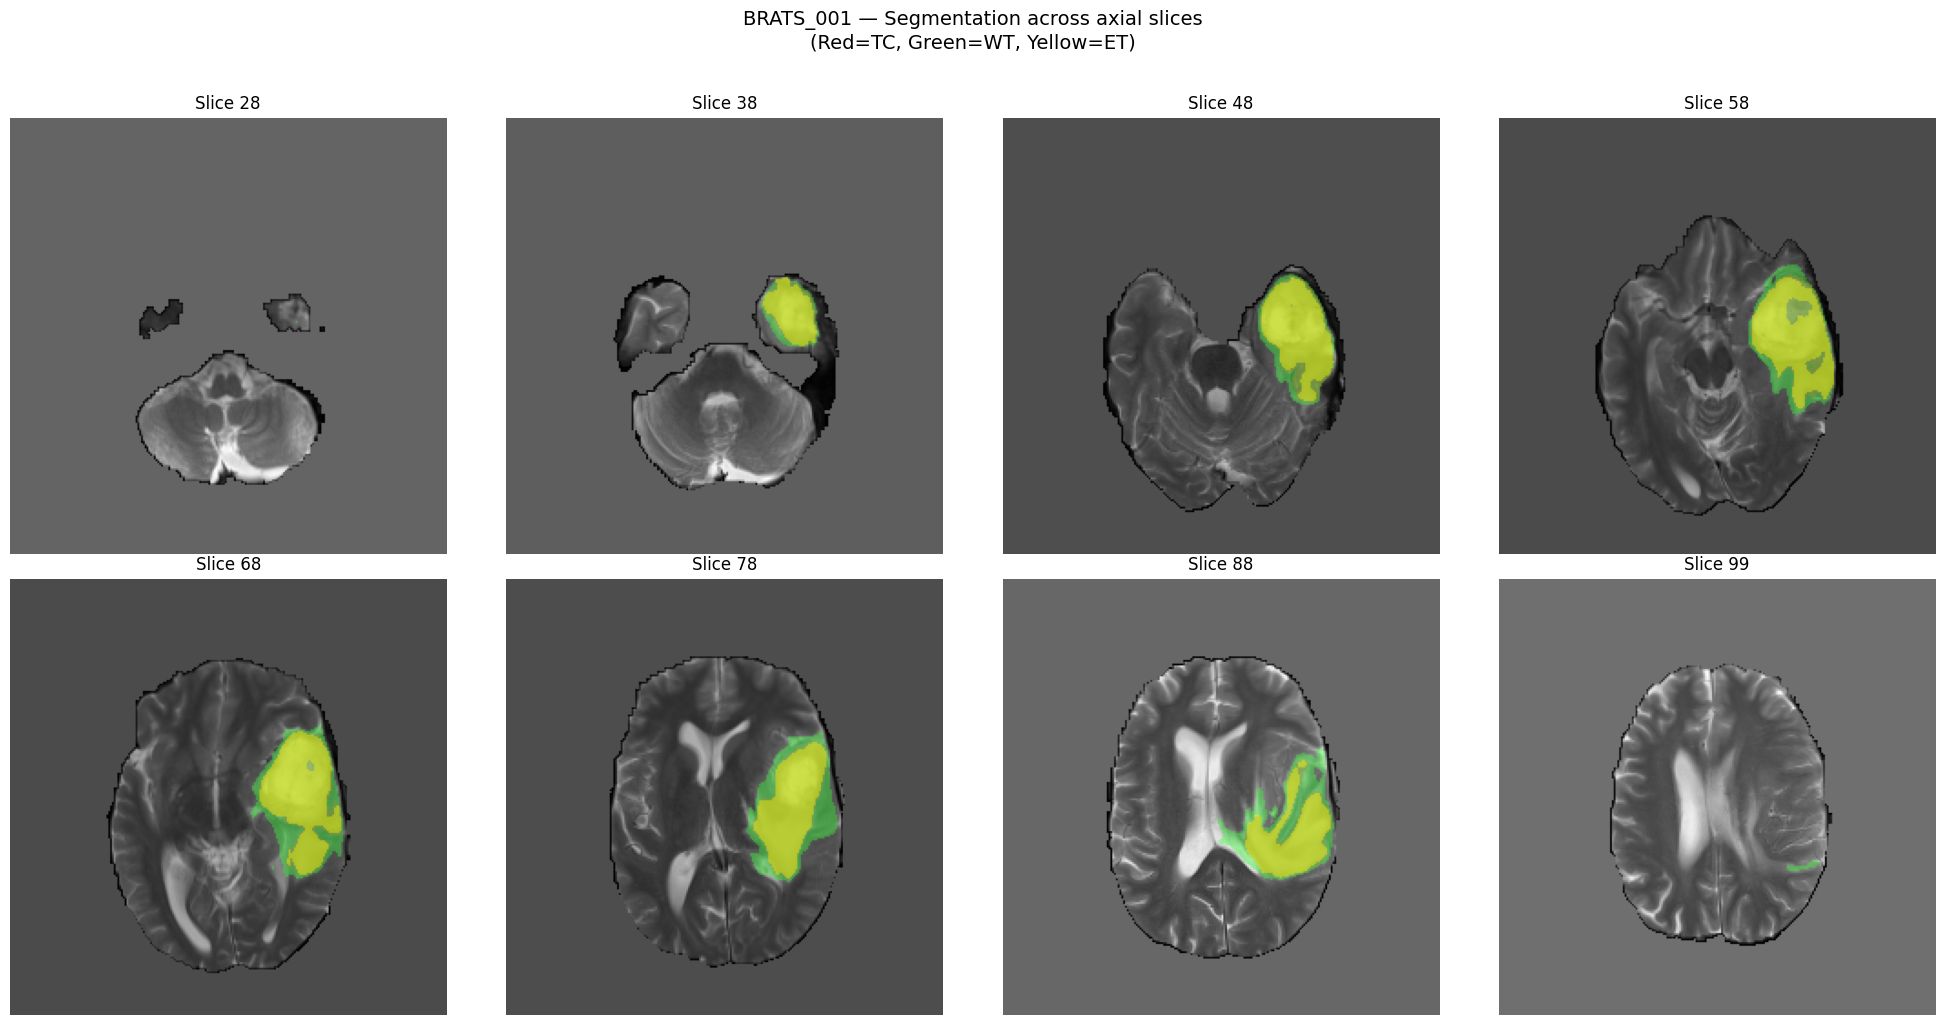

In [10]:
r = results[0]
flair = r["image"][3].numpy()
pred = r["pred"].numpy()

# Find slices with tumor, pick 8 evenly spaced
tumor_slices = np.where(pred.sum(axis=(0, 1, 2)) > 0)[0]
if len(tumor_slices) > 8:
    indices = np.linspace(0, len(tumor_slices) - 1, 8, dtype=int)
    selected = tumor_slices[indices]
else:
    selected = tumor_slices

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, sl in enumerate(selected):
    overlay = create_segmentation_overlay(flair[:, :, sl], pred[:, :, :, sl])
    axes[idx].imshow(overlay.transpose(1, 0, 2), origin="lower")
    axes[idx].set_title(f"Slice {sl}", fontsize=12)
    axes[idx].axis("off")

# Hide unused axes
for idx in range(len(selected), 8):
    axes[idx].axis("off")

fig.suptitle(f"{r['id']} — Segmentation across axial slices\n(Red=TC, Green=WT, Yellow=ET)", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "multi_slice_view.png", dpi=150, bbox_inches="tight")
plt.show()